Vamos construir um modelo de Regressão Linear para o conjunto de dados de custos médicos. O conjunto de dados é composto pelas variáveis independentes: idade, sexo, IMC (índice de massa corporal), número de filhos, tabagismo e região. A variável dependente é o custo (charge). Nosso objetivo será prever os custos médicos individuais cobrados por planos de saúde.

# Definição e Princípio de Funcionamento

Vamos construir um modelo usando **Regressão Linear**.

A regressão linear é um algoritmo de **aprendizado supervisionado** utilizado quando a variável alvo (dependente) é um número real **contínuo**. Ela estabelece uma relação entre a variável dependente $y$ e uma ou mais variáveis independentes $x$ por meio de uma linha de melhor ajuste. O modelo funciona com base no princípio dos mínimos quadrados ordinários *(OLS)* ou do erro quadrático médio *(MSE)*. 

Na estatística, o OLS é um método para estimar parâmetros desconhecidos de uma função de regressão linear. Seu objetivo é minimizar a soma dos quadrados das diferenças entre os valores observados da variável dependente no conjunto de dados e os valores previstos pela função de regressão linear.

## Representação da Hipótese

Vamos usar $\mathbf{x_i}$ para denotar a variável independente e $\mathbf{y_i}$ para denotar a variável dependente. Um par $\mathbf{(x_i, y_i)}$ é chamado de exemplo de treinamento. O índice $\mathbf{i}$ na notação é simplesmente a posição no conjunto de treinamento. Se temos $\mathbf{m}$ exemplos de treinamento, então $\mathbf{i = 1, 2, 3, ..., m}$.

O objetivo do aprendizado supervisionado é aprender uma *função hipótese $\mathbf{h}$*, para um dado conjunto de treinamento, que possa ser usada para estimar $\mathbf{y}$ com base em $\mathbf{x}$. Assim, a função hipótese é representada como:

$$\mathbf{ h_\theta(x_{i}) = \theta_0 + \theta_1x_i }$$

Onde $\mathbf{\theta_0, \theta_1}$ são os parâmetros da hipótese. Esta é a equação da **Regressão Linear Simples / Univariada**.

Para **Regressão Linear Múltipla**, onde há mais de uma variável independente, usamos $\mathbf{x_{ij}}$ para denotar a variável independente e $\mathbf{y_i}$ para denotar a variável dependente. Se temos $\mathbf{n}$ variáveis independentes, então $\mathbf{j = 1, 2, 3, ..., n}$. A função hipótese é representada como:

$$\mathbf{h_\theta(x_{i}) = \theta_0 + \theta_1x_{i1} + \theta_2 x_{i2} + \ldots + \theta_j x_{ij} + \ldots + \theta_n x_{in}}$$

Onde:

- $\mathbf{\theta_0, \theta_1, ..., \theta_j, ..., \theta_n}$ são os parâmetros da hipótese,  
- $\mathbf{m}$ é o número de exemplos de treinamento,  
- $\mathbf{n}$ é o número de variáveis independentes,  
- $\mathbf{x_{ij}}$ é o $\mathbf{i^{\text{ésimo}}}$ exemplo de treinamento da $\mathbf{j^{\text{ésima}}}$ variável.


## Importar Bibliotecas e Conjunto de Dados  
Agora vamos importar algumas bibliotecas do Python necessárias para a nossa análise e também importar o conjunto de dados.


In [2]:
import numpy as np # álgebra linear
import pandas as pd # processamento de dados, leitura de arquivos CSV (por exemplo: pd.read_csv)
import matplotlib.pyplot as plt # visualização de dados
import seaborn as sns # visualização estatística de dados
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('C:/Users/ofici/OneDrive/Documentos/estudos_prova_cientista/modelos/bases/insurance.csv')
print('\nNúmero de Linhas e Colunas',df.shape)
print('')

# top 5 linhas do dataset
df.head()


Número de Linhas e Colunas (1338, 7)



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Análise da Estrutura do Conjunto de Dados

Agora que importamos o conjunto de dados, ao observar sua estrutura (shape), vemos que ele possui (1338, 7). Ou seja, existem $\mathbf{m=1338}$ exemplos de treinamento e $\mathbf{n=7}$ variáveis no total.

A variável alvo aqui é `charges`, e as outras seis variáveis — `age`, `sex`, `bmi`, `children`, `smoker` e `region` — são variáveis independentes.

Como temos múltiplas variáveis independentes, devemos aplicar **Regressão Linear Múltipla**. Assim, a função hipótese para este conjunto de dados se torna:

$$
\mathbf{ h_\theta(x_{i}) = \theta_0+\theta_1 \cdot \text{age} + \theta_2 \cdot \text{sex} + \theta_3 \cdot \text{bmi} + \theta_4 \cdot \text{children} + \theta_5 \cdot \text{smoker} + \theta_6 \cdot \text{region} }
$$

Esta é a equação da regressão linear múltipla para o conjunto de dados.

### Exemplo para $i=1$

$$
\mathbf{h_\theta(x_{1}) = \theta_0+\theta_1 \cdot 19 + \theta_2 \cdot \text{female} + \theta_3 \cdot 27{,}900 + \theta_4 \cdot 1 + \theta_5 \cdot \text{yes} + \theta_6 \cdot \text{southwest}}
$$

$$
\mathbf{y_1 = 16884{,}92400}
$$

### Exemplo para $i=3$

$$
\mathbf{h_\theta(x_{3}) = \theta_0+\theta_1 \cdot 28 + \theta_2 \cdot \text{male} + \theta_3 \cdot 33{,}000 + \theta_4 \cdot 3 + \theta_5 \cdot \text{no} + \theta_6 \cdot \text{northwest}}
$$

$$
\mathbf{y_3 = 4449{,}46200}
$$

> **Nota**: No Python, os índices começam do 0.

A matriz de entrada para o primeiro exemplo pode ser representada como:

$$
\mathbf{x_1 = \left(\begin{matrix} x_{11} & x_{12} & x_{13} & x_{14} & x_{15} & x_{16}\end{matrix}\right) = \left(\begin{matrix} 19 & \text{female} & 27{,}900 & 1 & \text{no} & \text{northwest}\end{matrix}\right)}
$$


## Formulação Matricial

De forma geral, podemos escrever o vetor acima como:

$$ 
\mathbf{ x_{ij}} = \left( \begin{smallmatrix} \mathbf{x_{i1}} & \mathbf{x_{i2}} & . & . & . & \mathbf{x_{in}} \end{smallmatrix} \right) 
$$

Agora combinamos todos os vetores individuais disponíveis em uma única matriz de entrada de dimensão $(m,n)$, que denotamos por $\mathbf{X}$ — a **matriz de entrada**, que contém todos os exemplos de treinamento:

$$
\mathbf{X} = \left( 
\begin{smallmatrix} 
x_{11} & x_{12} & . & . & . & x_{1n} \\
x_{21} & x_{22} & . & . & . & x_{2n} \\
x_{31} & x_{32} & . & . & . & x_{3n} \\
. & . & . & . & . & . \\
. & . & . & . & . & . \\
x_{m1} & x_{m2} & . & . & . & x_{mn} \\
\end{smallmatrix} 
\right)_{(m,n)}
$$

Representamos os parâmetros da função e a variável dependente em forma vetorial como:

$$
\theta = \left(
\begin{matrix}
\theta_0 \\
\theta_1 \\
. \\
. \\
\theta_j \\
. \\
\theta_n
\end{matrix}
\right)_{(n+1,1)} 
\quad 
\mathbf{y} = \left(
\begin{matrix}
y_1 \\
y_2 \\
. \\
. \\
y_i \\
. \\
y_m
\end{matrix}
\right)_{(m,1)}
$$

Assim, podemos representar a **função hipótese** em forma vetorizada como:

$$
\mathbf{h_\theta(x)} = X\theta
$$


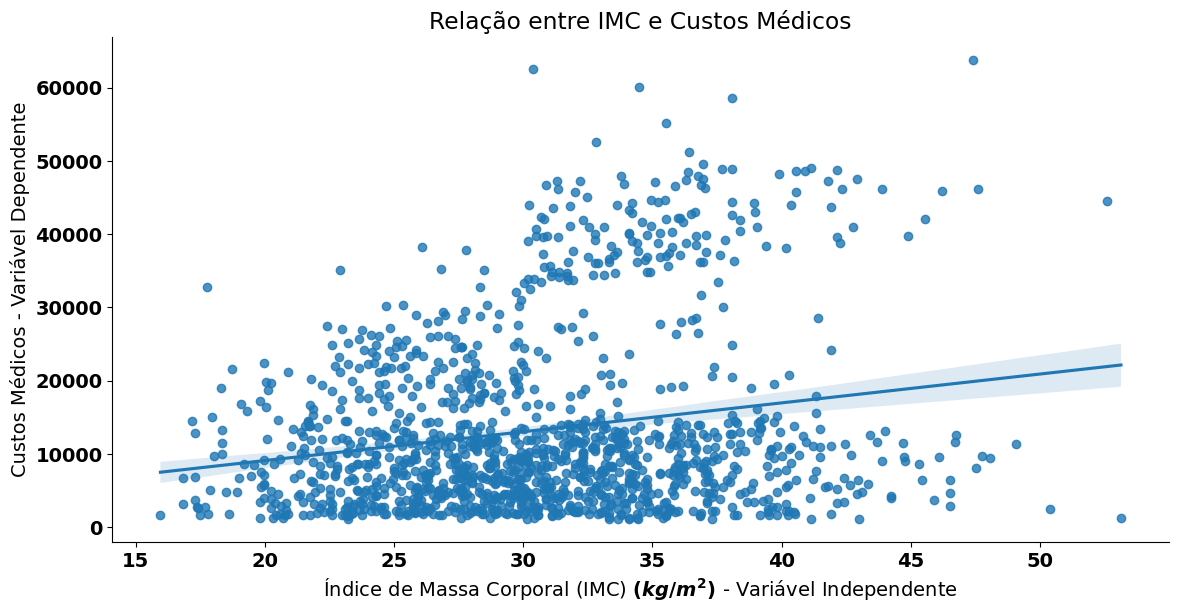

In [5]:
# Para fins de visualização, ajustaremos uma linha de regressão simples
# considerando apenas o IMC (bmi) como variável independente
# e os custos (charges) como variável dependente

sns.lmplot(x='bmi', y='charges', data=df, aspect=2, height=6)
plt.xlabel('Índice de Massa Corporal (IMC) $(kg/m^2)$ - Variável Independente')
plt.ylabel('Custos Médicos - Variável Dependente')
plt.title('Relação entre IMC e Custos Médicos')
plt.show()

No gráfico acima, ajustamos uma linha de regressão às variáveis.

## Função de Custo

A função de custo mede o quanto de erro o modelo possui em termos da sua capacidade de estimar a relação entre $x$ e $y$.  
Podemos medir a precisão da nossa função hipótese utilizando uma função de custo. Ela calcula a média das diferenças entre os valores observados da variável dependente no conjunto de dados e os valores previstos pela função hipótese.

$$
J(\theta) = \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2
$$

$$
J(\theta) = \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x_i) - y_i)^2
$$

Para implementar a regressão linear, tomamos os exemplos de treinamento e adicionamos uma coluna extra chamada de $x_0$, onde $x_0 = 1$.

$$
x_i = \left( \begin{matrix} x_{i0} & x_{i1} & x_{i2} & \cdots & x_{in} \end{matrix} \right), \quad x_{i0} = 1
$$

A matriz de entrada $X$ então se torna:

$$
X =
\begin{pmatrix}
x_{10} & x_{11} & \cdots & x_{1n} \\
x_{20} & x_{21} & \cdots & x_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
x_{m0} & x_{m1} & \cdots & x_{mn}
\end{pmatrix}_{(m, n+1)}
$$

Cada linha representa uma amostra, e cada coluna uma variável (com $x_0 = 1$). Agora reescrevemos a função de custo dos mínimos quadrados ordinários em forma matricial:

$$
J(\theta) = \frac{1}{m} (X\theta - y)^T (X\theta - y)
$$

**Dimensões envolvidas:**

- $X$ possui dimensão $(m, n+1)$  
- $\theta$ possui dimensão $(n+1, 1)$  
- $y$ possui dimensão $(m, 1)$

O produto $X\theta$ resulta em um vetor $(m, 1)$ com as predições para cada observação.  
Subtraindo $y$ de $X\theta$ temos um vetor $(m, 1)$ com os erros de predição.  
Multiplicando pela transposta resulta em um escalar, que representa a função de custo.

## Equação Normal

A equação normal é uma solução analítica para o problema de regressão linear com uma função de custo de mínimos quadrados ordinários. Para minimizar a função de custo, tomamos a derivada parcial de $\mathbf{J(\theta)}$ em relação a $\theta$ e igualamos a zero. A derivada de uma função indica quanto a saída muda em relação a uma pequena mudança na entrada.

$$\mathbf{\min_{\theta_0,\theta_1..\theta_n} J({\theta_0,\theta_1..\theta_n})}$$  
$$\mathbf{\frac{\partial J(\theta_j)}{\partial\theta_j} = 0}$$  
onde $\mathbf{j = 0,1,2,\dots,n}$

Agora aplicamos a derivada parcial na função de custo:

$$\mathbf{\frac{\partial J(\theta)}{\partial\theta} = \frac{\partial }{\partial \theta} \frac{1}{m}(X\theta - y)^T(X\theta - y)}$$

Vamos ignorar o termo $\frac{1}{m}$ por enquanto, pois ele é constante ao derivar. Expandimos $\mathbf{J(\theta)}$:

$$\mathbf{J(\theta) = (X\theta - y)^T(X\theta - y)}$$  
$$= (X\theta)^T X\theta - y^T X\theta - \theta^T X^T y + y^T y$$  
$$= \theta^T X^T X \theta - 2\theta^T X^T y + y^T y$$

Note que:  
$\mathbf{y^T X \theta = \theta^T X^T y}$ (pois são escalares)

Agora derivamos:

$$\mathbf{\frac{\partial J(\theta)}{\partial\theta} = \frac{\partial}{\partial \theta} \left( \theta^T X^T X \theta - 2\theta^T X^T y + y^T y \right)}$$  
$$= 2 X^T X \theta - 2 X^T y$$

Igualando a zero:

$$0 = 2X^T X \theta - 2X^T y$$  
$$X^T X \theta = X^T y$$  
$$\boxed{\theta = (X^T X)^{-1} X^T y}$$

Essa é a **equação normal** usada para resolver a regressão linear de forma direta e exata (quando $X^T X$ é invertível).

# Análise Exploratória

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


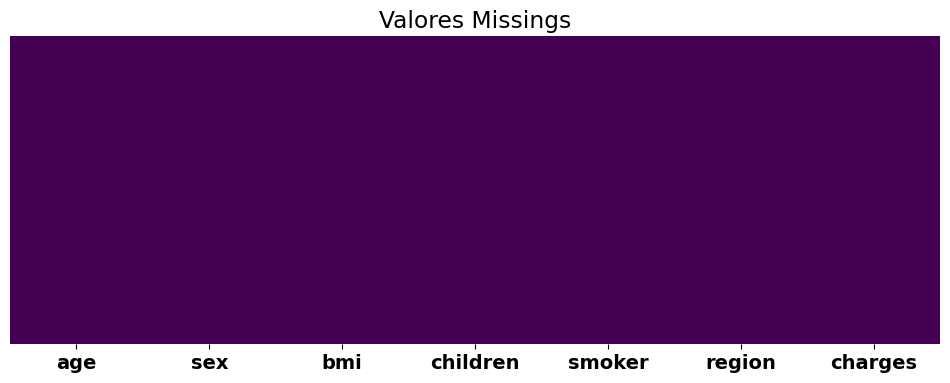

In [8]:
plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Valores Missings');

<Axes: >

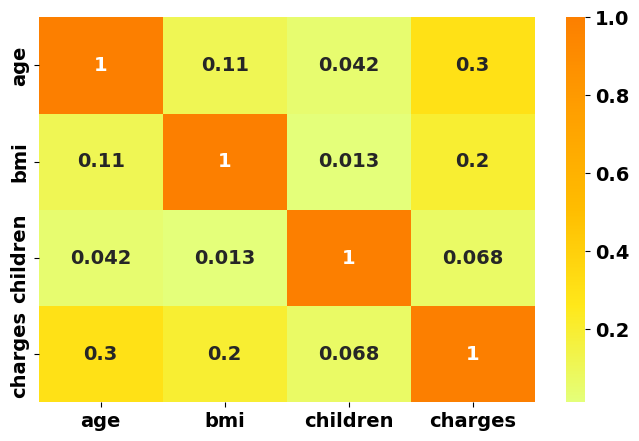

In [10]:
# Gráfico de correlação apenas para variáveis numéricas
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, cmap='Wistia', annot=True)

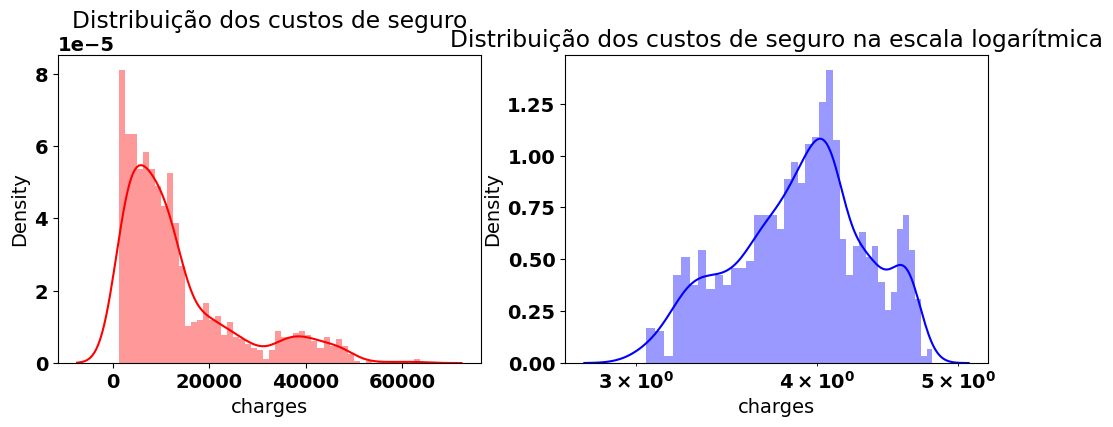

In [11]:
# Criando uma figura com tamanho personalizado
f = plt.figure(figsize=(12, 4))

# Primeiro subplot: distribuição dos valores originais de 'charges'
ax = f.add_subplot(121)
sns.distplot(df['charges'], bins=50, color='r', ax=ax)
ax.set_title('Distribuição dos custos de seguro')

# Segundo subplot: distribuição dos valores transformados com log de base 10
ax = f.add_subplot(122)
sns.distplot(np.log10(df['charges']), bins=40, color='b', ax=ax)
ax.set_title('Distribuição dos custos de seguro na escala logarítmica')
ax.set_xscale('log')

Se observarmos o gráfico à esquerda, os custos variam de 1120 a 63.500, e a distribuição apresenta assimetria à direita (distribuição enviesada positivamente). 

No gráfico à direita, aplicamos o logaritmo natural nos valores, e então a distribuição se aproxima de uma normal. 

Para as análises posteriores, aplicaremos o logaritmo na variável alvo `charges`.


Text(0.5, 1.0, 'Gráfico de violino: Custos vs Fumante')

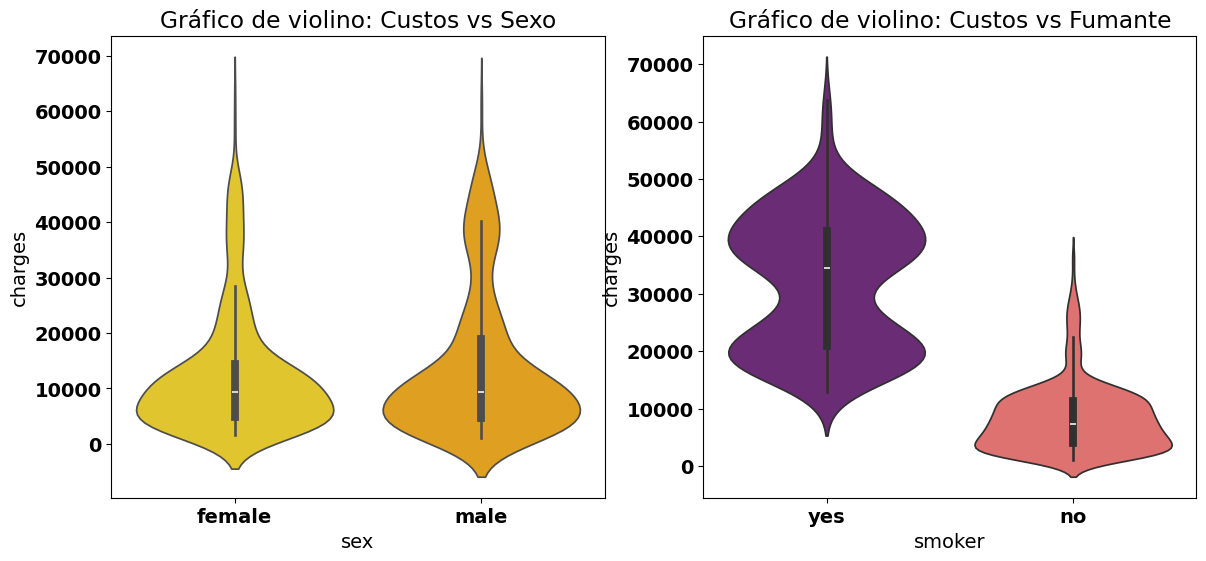

In [12]:
# Criando uma figura com tamanho personalizado
f = plt.figure(figsize=(14, 6))

# Primeiro gráfico: violino comparando os custos por sexo
ax = f.add_subplot(121)
sns.violinplot(x='sex', y='charges', data=df, palette='Wistia', ax=ax)
ax.set_title('Gráfico de violino: Custos vs Sexo')

# Segundo gráfico: violino comparando os custos por hábito de fumar
ax = f.add_subplot(122)
sns.violinplot(x='smoker', y='charges', data=df, palette='magma', ax=ax)
ax.set_title('Gráfico de violino: Custos vs Fumante')


No gráfico à esquerda, os custos de seguro para homens e mulheres estão aproximadamente na mesma faixa, com uma média em torno de 5.000 dólares. No gráfico à direita, os custos de seguro para fumantes apresentam uma faixa muito mais ampla em comparação aos não fumantes. Para os não fumantes, a média dos custos é de aproximadamente 5.000 dólares. Já para os fumantes, o valor mínimo do custo do seguro já parte de 5.000 dólares.

Text(0.5, 1.0, 'Gráfico de Caixa: Custos vs Número de Filhos')

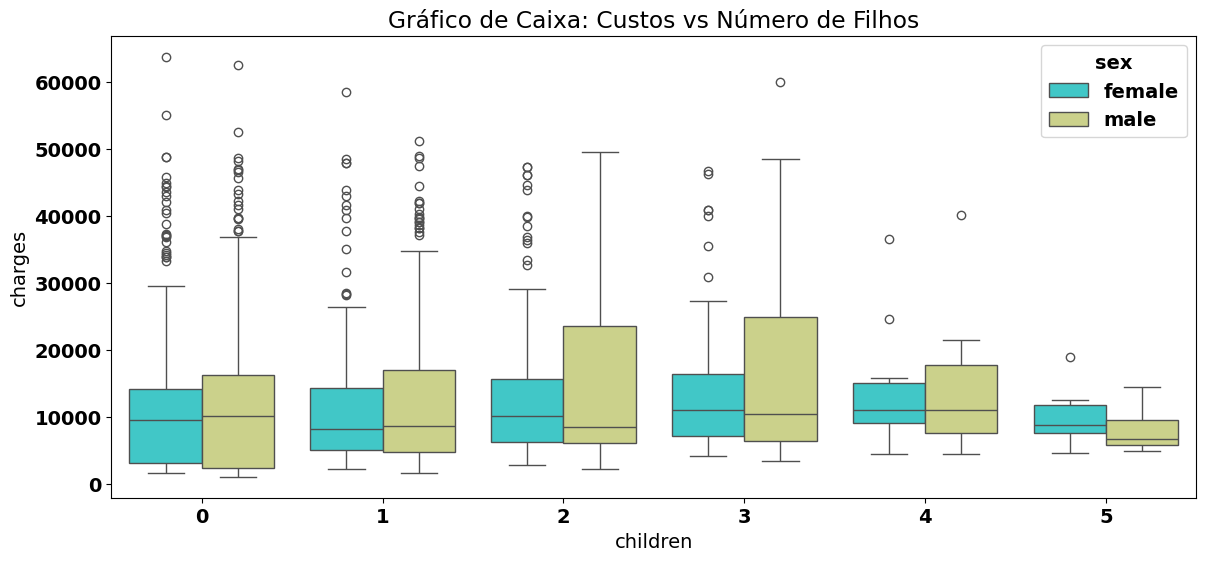

In [13]:
# Criar um gráfico de caixa (boxplot) dos custos vs número de filhos, separados por sexo
plt.figure(figsize=(14, 6))
sns.boxplot(x='children', y='charges', hue='sex', data=df, palette='rainbow')
plt.title('Gráfico de Caixa: Custos vs Número de Filhos')

In [15]:
# Agrupar os dados pelo número de filhos e calcular a média, o mínimo e o máximo dos custos de seguro
df.groupby('children')['charges'].agg(['mean', 'min', 'max'])

,mean,min,max
children,,,
0,12365.975602,1121.8739,63770.42801
1,12731.171832,1711.0268,58571.07448
2,15073.563734,2304.0022,49577.66240
3,15355.318367,3443.0640,60021.39897
4,13850.656311,4504.6624,40182.24600
5,8786.035247,4687.7970,19023.26000


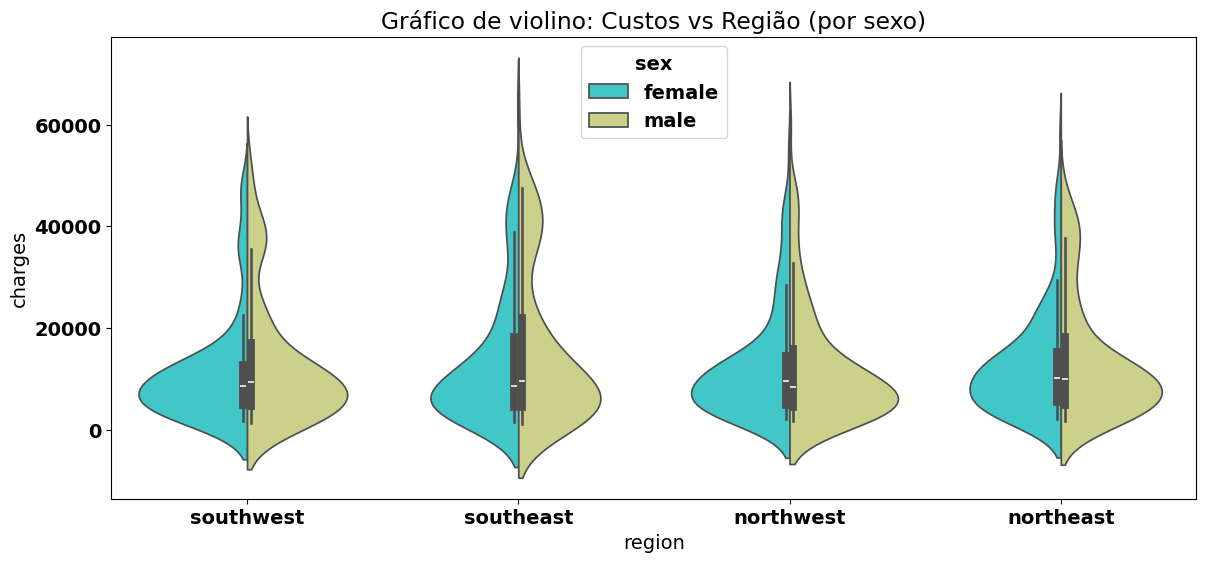

In [16]:
# Criando um gráfico de violino dos custos por região, separados por sexo
plt.figure(figsize=(14, 6))
sns.violinplot(x='region', y='charges', hue='sex', data=df, palette='rainbow', split=True)
plt.title('Gráfico de violino: Custos vs Região (por sexo)');

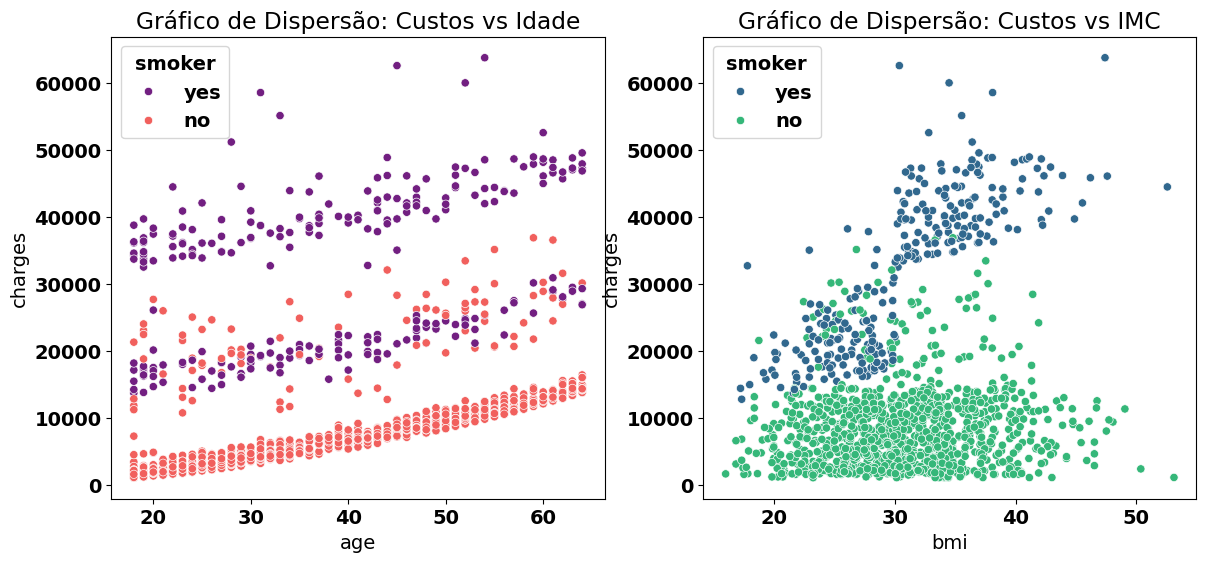

In [17]:
# Criando gráficos de dispersão dos custos em relação à idade e ao IMC, diferenciando fumantes e não fumantes
f = plt.figure(figsize=(14, 6))

ax = f.add_subplot(121)
sns.scatterplot(x='age', y='charges', data=df, palette='magma', hue='smoker', ax=ax)
ax.set_title('Gráfico de Dispersão: Custos vs Idade')

ax = f.add_subplot(122)
sns.scatterplot(x='bmi', y='charges', data=df, palette='viridis', hue='smoker')
ax.set_title('Gráfico de Dispersão: Custos vs IMC')

plt.savefig('sc.png');

> No gráfico da esquerda, observamos que a idade mínima de uma pessoa segurada é 18 anos. Existem faixas (slabs) nas apólices: a maioria dos não fumantes se enquadra na 1ª e 2ª faixas, enquanto para fumantes a apólice geralmente começa a partir da 2ª ou 3ª faixa.

> O Índice de Massa Corporal (IMC) é uma medida de gordura corporal baseada na altura e peso, aplicável a homens e mulheres adultos. O IMC mínimo observado é de 16 kg/m² e o máximo chega a 54 kg/m².


## Pré-processamento de Dados

### Codificação (Encoding)

Os algoritmos de machine learning não conseguem trabalhar diretamente com dados categóricos — esses dados precisam ser convertidos em valores numéricos.

1. **Label Encoding (Codificação por Rótulo)**  
2. **One-Hot Encoding (Codificação One-Hot)**  
3. **Armadilha de Variável Dummy (Dummy Variable Trap)**

**Label encoding** refere-se à transformação de rótulos em texto (como "masculino" e "feminino") para uma forma numérica (como 0 e 1), permitindo que os algoritmos processem os dados.

**One-hot encoding** é uma representação de variáveis categóricas em vetores binários. Ela torna a representação dos dados categóricos mais expressiva. Primeiro, os valores categóricos são mapeados para inteiros (label encoding). Em seguida, cada valor inteiro é representado como um vetor binário, com todos os valores sendo zero, exceto no índice correspondente ao valor categórico, que recebe 1.

A **armadilha de variável dummy** ocorre quando variáveis independentes são multicolineares, ou seja, quando duas ou mais variáveis estão altamente correlacionadas — em termos simples, uma variável pode ser prevista pelas outras.

Felizmente, usando a função `get_dummies` do *pandas*, conseguimos aplicar os três passos acima em uma única linha de código. Utilizaremos essa função para gerar variáveis dummies para as colunas `sex`, `children`, `smoker` e `region`. Ao definir `drop_first=True`, eliminamos automaticamente a armadilha de variável dummy ao descartar uma categoria e a variável original.

O `pandas` realmente facilita a nossa vida!


In [18]:
# Variáveis Dummy
categorical_columns = ['sex', 'children', 'smoker', 'region']
df_encode = pd.get_dummies(
    data=df,
    prefix='OHE',
    prefix_sep='_',
    columns=categorical_columns,
    drop_first=True,
    dtype='int8'
)

In [19]:
# Vamos verificar o processo de criação das variáveis dummies
print('Colunas no DataFrame original:\n', df.columns.values)
print('\nNúmero de linhas e colunas no conjunto de dados:', df.shape)
print('\nColunas no DataFrame após a codificação das variáveis dummies:\n', df_encode.columns.values)
print('\nNúmero de linhas e colunas no conjunto de dados:', df_encode.shape)


Colunas no DataFrame original:
 ['age' 'sex' 'bmi' 'children' 'smoker' 'region' 'charges']

Número de linhas e colunas no conjunto de dados: (1338, 7)

Colunas no DataFrame após a codificação das variáveis dummies:
 ['age' 'bmi' 'charges' 'OHE_male' 'OHE_1' 'OHE_2' 'OHE_3' 'OHE_4' 'OHE_5'
 'OHE_yes' 'OHE_northwest' 'OHE_southeast' 'OHE_southwest']

Número de linhas e colunas no conjunto de dados: (1338, 13)


### Transformação de Box-Cox

A transformação de Box-Cox é uma maneira de transformar variáveis dependentes que não seguem uma distribuição normal em uma forma mais próxima da normal. A normalidade é uma suposição importante para muitas técnicas estatísticas; se os seus dados não forem normais, aplicar a transformação de Box-Cox permite que você utilize uma gama mais ampla de testes. 

Tudo o que precisamos para realizar essa transformação é encontrar o valor de lambda ($\lambda$) e aplicar a seguinte regra à sua variável:

$$
\mathbf{ 
\begin{cases}
\frac{y^\lambda - 1}{\lambda}, & \text{se } \lambda \ne 0 \\
\log(y), & \text{se } \lambda = 0
\end{cases}
}
$$

O segredo da transformação de Box-Cox está em encontrar o valor ideal de $\lambda$. No entanto, na prática isso é bastante acessível. A função a seguir retorna a variável transformada, o valor de $\lambda$ e o intervalo de confiança.


In [20]:
from scipy.stats import boxcox

# Aplicando a transformação de Box-Cox na variável 'charges'
y_bc, lam, ci = boxcox(df_encode['charges'], alpha=0.05)

# df['charges'] = y_bc  
# A transformação de Box-Cox não apresentou melhor desempenho neste modelo,
# portanto, optou-se por utilizar a transformação logarítmica.

ci, lam

((-0.01140290617294196, 0.0988096859767545), 0.043649053770664956)

In [21]:
# Aplicando transformação logarítmica natural à variável 'charges'
df_encode['charges'] = np.log(df_encode['charges'])

As variáveis categóricas originais foram removidas e também uma das colunas de variáveis *one-hot encoded* para cada variável categórica foi descartada. Dessa forma, completamos as três etapas de codificação utilizando a função `get_dummies` do Pandas.


In [22]:
# Teino e Teste

from sklearn.model_selection import train_test_split
X = df_encode.drop('charges',axis=1) # features
y = df_encode['charges'] # target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=23)

## Construção do Modelo

Nesta etapa, construiremos o modelo usando nossa equação de regressão linear:  
$\mathbf{\theta = (X^T X)^{-1} X^T y}$.

No primeiro passo, precisamos adicionar uma variável $\mathbf{x_0 = 1}$ ao nosso conjunto de dados original.


In [24]:
# Etapa 1: adicionar x0 = 1 ao conjunto de dados
X_train_0 = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_0 = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Etapa 2: construir o modelo
theta = np.matmul(
    np.linalg.inv(np.matmul(X_train_0.T, X_train_0)),
    np.matmul(X_train_0.T, y_train)
)

In [25]:
# Parâmetros do modelo de regressão linear
parametros = ['theta_' + str(i) for i in range(X_train_0.shape[1])]
colunas = ['intercepto: x_0 = 1'] + list(X.columns.values)

parametros_df = pd.DataFrame({
    'Parâmetro': parametros,
    'Variável': colunas,
    'Valor de θ': theta
})

parametros_df

,Parâmetro,Variável,Valor de θ
0,theta_0,intercepto: x_0 = 1,7.059171
1,theta_1,age,0.033134
2,theta_2,bmi,0.013517
3,theta_3,OHE_male,-0.067767
4,theta_4,OHE_1,0.149457
5,theta_5,OHE_2,0.272919
6,theta_6,OHE_3,0.244095
7,theta_7,OHE_4,0.523339
8,theta_8,OHE_5,0.466030
9,theta_9,OHE_yes,1.550481


In [26]:
# Módulo Scikit-Learn
from sklearn.linear_model import LinearRegression

# Instancia e treina o modelo de Regressão Linear
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)  # Nota: não é necessário adicionar x_0 = 1, o Scikit-Learn já cuida disso.

# Parâmetros do modelo treinado
sk_theta = [lin_reg.intercept_] + list(lin_reg.coef_)

# Adiciona os parâmetros obtidos pelo Scikit-Learn ao DataFrame
parametros_df = parametros_df.join(pd.Series(sk_theta, name='Theta_Sklearn'))

parametros_df


,Parâmetro,Variável,Valor de θ,Theta_Sklearn
0,theta_0,intercepto: x_0 = 1,7.059171,7.059171
1,theta_1,age,0.033134,0.033134
2,theta_2,bmi,0.013517,0.013517
3,theta_3,OHE_male,-0.067767,-0.067767
4,theta_4,OHE_1,0.149457,0.149457
5,theta_5,OHE_2,0.272919,0.272919
6,theta_6,OHE_3,0.244095,0.244095
7,theta_7,OHE_4,0.523339,0.523339
8,theta_8,OHE_5,0.466030,0.466030
9,theta_9,OHE_yes,1.550481,1.550481


### Avaliação do Modelo

Os parâmetros obtidos por ambos os modelos são iguais. Portanto, construímos com sucesso nosso modelo utilizando a equação normal e o verificamos com o módulo de regressão linear do Scikit-Learn.

Vamos seguir em frente: o próximo passo é realizar as **predições** e a **avaliação do modelo**.


## Avaliação do Modelo

Vamos prever os valores da variável alvo usando os parâmetros do nosso modelo no conjunto de teste. Em seguida, comparamos os valores previstos com os valores reais presentes nesse conjunto.

Calculamos o **Erro Quadrático Médio (MSE)** utilizando a fórmula:

$$\mathbf{ J(\theta) = \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2}$$

O $\mathbf{R^2}$ é uma medida estatística que indica o quão próximos os dados estão da linha de regressão ajustada. O valor de $\mathbf{R^2}$ está sempre entre 0% e 100%.  
- **0%** indica que o modelo não explica nenhuma variabilidade dos dados em torno da média.  
- **100%** indica que o modelo explica toda a variabilidade dos dados em torno da média.

A fórmula é:

$$\mathbf{R^2 = 1 - \frac{SSE}{SST}}$$

Onde:
- **SSE** = Soma dos Erros Quadráticos (Sum of Square Error)  
- **SST** = Soma Total dos Quadrados (Sum of Square Total)

$$\mathbf{SSE = \sum_{i=1}^{m}(\hat{y}_i - y_i)^2}$$  
$$\mathbf{SST = \sum_{i=1}^{m}(y_i - \bar{y})^2}$$

Aqui, $\mathbf{\hat{y}}$ representa os valores previstos e $\mathbf{\bar{y}}$ é a média dos valores reais $\mathbf{y}$.


In [27]:
# Equação normal
y_pred_norm = np.matmul(X_test_0, theta)

# Avaliação: Erro Quadrático Médio (MSE)
J_mse = np.sum((y_pred_norm - y_test)**2) / X_test_0.shape[0]

# R² (Coeficiente de Determinação)
sse = np.sum((y_pred_norm - y_test)**2)
sst = np.sum((y_test - y_test.mean())**2)
R_square = 1 - (sse / sst)

print('O Erro Quadrático Médio (MSE) ou J(theta) é: ', J_mse)
print('O R² obtido pelo método da equação normal é: ', R_square)

O Erro Quadrático Médio (MSE) ou J(theta) é:  0.18729622322981948
O R² obtido pelo método da equação normal é:  0.7795687545055312


In [28]:
# Regressão usando o módulo sklearn
y_pred_sk = lin_reg.predict(X_test)

# Avaliação: Erro Quadrático Médio (MSE)
from sklearn.metrics import mean_squared_error
J_mse_sk = mean_squared_error(y_pred_sk, y_test)

# R² (Coeficiente de Determinação)
R_square_sk = lin_reg.score(X_test, y_test)

print('O Erro Quadrático Médio (MSE) ou J(theta) é: ', J_mse_sk)
print('O R² obtido usando a biblioteca scikit-learn é: ', R_square_sk)

O Erro Quadrático Médio (MSE) ou J(theta) é:  0.18729622322981898
O R² obtido usando a biblioteca scikit-learn é:  0.7795687545055318


O modelo retorna um valor de $R^2$ de **77,95%**, o que indica que ele se ajusta muito bem aos dados de teste. No entanto, ainda podemos melhorar o desempenho utilizando diferentes técnicas.

É importante observar que transformamos a variável de saída aplicando o logaritmo natural. Quando o modelo for colocado em produção, o **antilogaritmo** (função exponencial) deverá ser aplicado à equação para retornar os valores ao seu formato original.


## Validação do Modelo

Para validar um modelo de regressão linear, é necessário verificar algumas suposições fundamentais. As suposições mais comuns para modelos de *Regressão Linear* são as seguintes:

1. **Relação Linear**: Na regressão linear, a relação entre a variável dependente e as variáveis independentes deve ser *linear*. Isso pode ser verificado por meio de um gráfico de dispersão entre os valores reais e os valores previstos.

2. **Distribuição Normal dos Resíduos**: O gráfico dos erros residuais deve apresentar uma distribuição aproximadamente *normal*.

3. **Média dos Erros Residuais Igual a Zero**: A *média* dos erros residuais deve ser igual ou o mais próxima possível de 0.

4. **Normalidade Multivariada**: A regressão linear assume que todas as variáveis seguem uma distribuição normal multivariada. Essa suposição pode ser melhor verificada com um gráfico Q-Q (*Quantile-Quantile*).

5. **Ausência de Multicolinearidade**: A regressão linear assume que não há ou há pouca *multicolinearidade* nos dados. A multicolinearidade ocorre quando as variáveis independentes são altamente correlacionadas entre si. O *Fator de Inflação da Variância (VIF)* identifica a correlação entre variáveis independentes e a força dessa correlação. 

   $$\mathbf{VIF = \frac{1}{1 - R^2}}$$

   - Se VIF > 1 e VIF < 5: correlação moderada  
   - Se VIF ≥ 5: nível crítico de multicolinearidade

6. **Homoscedasticidade**: Os dados devem ser *homocedásticos*, ou seja, os resíduos devem apresentar variância constante ao longo da linha de regressão. Isso pode ser avaliado com um gráfico de dispersão dos resíduos versus os valores ajustados. Se houver *heterocedasticidade*, o gráfico apresentará um padrão em forma de funil.


Text(0.5, 1.0, 'Verificação da Normalidade e Média dos Resíduos:\n Erro Residual')

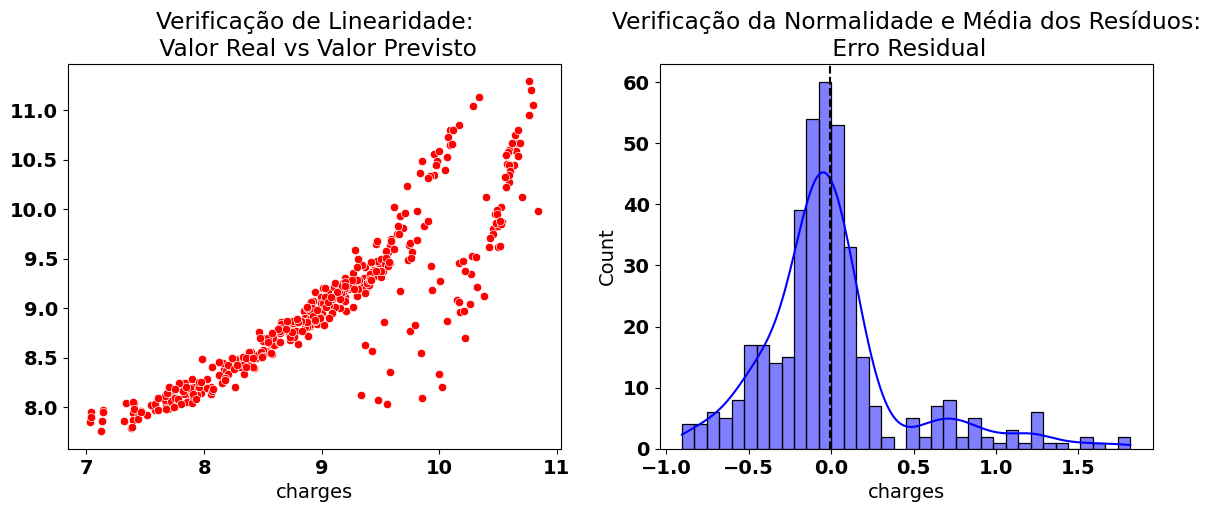

In [30]:
# Verificação da Linearidade e Normalidade dos Resíduos
f = plt.figure(figsize=(14,5))

# Gráfico de Dispersão: Valores Reais vs Previstos
ax = f.add_subplot(121)
sns.scatterplot(x=y_test, y=y_pred_sk, ax=ax, color='r')
ax.set_title('Verificação de Linearidade:\n Valor Real vs Valor Previsto')

# Verificação da Normalidade dos Resíduos e da Média
ax = f.add_subplot(122)
sns.histplot((y_test - y_pred_sk), ax=ax, color='b', kde=True)
ax.axvline((y_test - y_pred_sk).mean(), color='k', linestyle='--')
ax.set_title('Verificação da Normalidade e Média dos Resíduos:\n Erro Residual')

Text(0.5, 1.0, 'Verificação da Homocedasticidade: \nResíduo vs Valor Previsto')

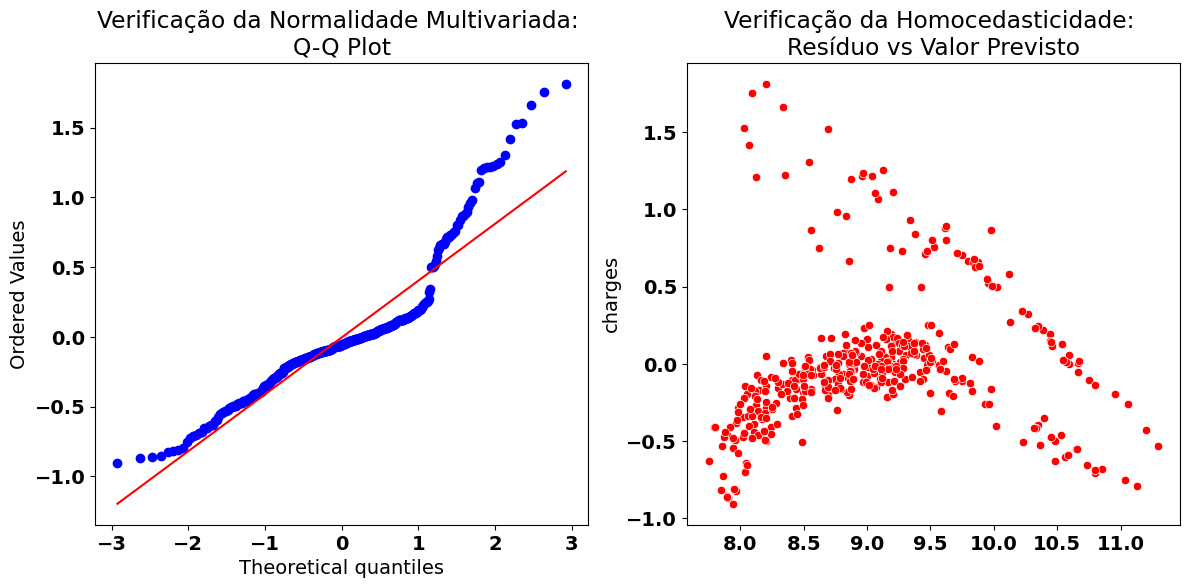

In [31]:
# Verificação da Normalidade Multivariada
# Gráfico Quantile-Quantile (Q-Q Plot)
f, ax = plt.subplots(1, 2, figsize=(14, 6))
import scipy as sp

# Geração do Q-Q Plot
_, (_, _, r) = sp.stats.probplot((y_test - y_pred_sk), fit=True, plot=ax[0])
ax[0].set_title('Verificação da Normalidade Multivariada: \nQ-Q Plot')

# Verificação da Homocedasticidade
# Gráfico de resíduos vs valores previstos
sns.scatterplot(y=(y_test - y_pred_sk), x=y_pred_sk, ax=ax[1], color='r')
ax[1].set_title('Verificação da Homocedasticidade: \nResíduo vs Valor Previsto')


In [32]:
# Verificação de Multicolinearidade
# Fator de Inflação da Variância (VIF)
VIF = 1 / (1 - R_square_sk)
VIF


4.536561945911135

### Verificação das Suposições do Modelo de Regressão Linear

1. **Linearidade**: No gráfico de valores reais vs. previstos, observa-se uma curva, o que indica que a suposição de linearidade **falha**.

2. **Erro com média zero**: A média dos resíduos é próxima de zero, porém o histograma dos erros mostra uma **assimetria à direita**, o que viola a normalidade dos resíduos.

3. **Normalidade dos resíduos**: O gráfico Q-Q indica que para valores logarítmicos acima de 1.5, os resíduos tendem a se afastar da linha, o que **compromete a normalidade** dos erros.

4. **Homoscedasticidade**: O gráfico de resíduos vs. valores previstos **exibe heterocedasticidade**, ou seja, os erros aumentam após certo ponto. Isso indica **variância não constante** dos erros.

5. **Ausência de multicolinearidade**: O **Fator de Inflação da Variância (VIF)** foi inferior a 5, o que indica que **não há multicolinearidade** significativa entre as variáveis independentes.
